<a href="https://colab.research.google.com/github/aniket9608/Network-Intrusion-Detection-System/blob/main/AI_NIDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os

# Download/access dataset
dataset_path = kagglehub.dataset_download("dhoogla/cicids2017")

# Find all Parquet files
parquet_files = [
    os.path.join(dataset_path, f)
    for f in os.listdir(dataset_path)
    if f.endswith(".parquet")
]

print("Parquet files found:", len(parquet_files))

# Load and combine all files
dfs = []

for file in parquet_files:
    print("Loading:", os.path.basename(file))

    temp_df = pd.read_parquet(file)
    dfs.append(temp_df)

# Combine into one DataFrame
df = pd.concat(dfs, ignore_index=True)

print("\nCombined dataset shape:", df.shape)
print("Rows:", len(df))
print("Columns:", len(df.columns))

# Save as one CSV
output_file = "/content/cicids2017_combined.csv"
df.to_csv(output_file, index=False)

print("\nSaved to:")
print(output_file)

# Preview
display(df.head())


Using Colab cache for faster access to the 'cicids2017' dataset.
Parquet files found: 8
Loading: Benign-Monday-no-metadata.parquet
Loading: Bruteforce-Tuesday-no-metadata.parquet
Loading: Portscan-Friday-no-metadata.parquet
Loading: WebAttacks-Thursday-no-metadata.parquet
Loading: DoS-Wednesday-no-metadata.parquet
Loading: DDoS-Friday-no-metadata.parquet
Loading: Infiltration-Thursday-no-metadata.parquet
Loading: Botnet-Friday-no-metadata.parquet

Combined dataset shape: (2313810, 78)
Rows: 2313810
Columns: 78

Saved to:
/content/cicids2017_combined.csv


,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,4,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
1,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
2,6,3,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
3,6,1,2,0,12,0,6,6,6.00000,0.000000,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign
4,6,609,7,4,484,414,233,0,69.14286,111.967896,...,20,0.0,0.0,0,0,0.0,0.0,0,0,Benign


In [ ]:
import pandas as pd
import numpy as np

file_path = "/content/cicids2017_combined.csv"

df = pd.read_csv(file_path)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nLabel/value counts:")
print(df.iloc[:, -1].value_counts())



# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Remove duplicate rows
df = df.drop_duplicates()

# Replace infinite values
df = df.replace([np.inf, -np.inf], np.nan)

# Remove rows containing NaN
df = df.dropna()

print(df.columns.tolist())



Dataset shape: (2313810, 78)

Columns:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Fla

In [ ]:
X = df.drop(columns=["Label"])
y = df["Label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClasses:")
print(y.value_counts())


X shape: (2231806, 77)
y shape: (2231806,)

Classes:
Label
Benign                        1895314
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack � Brute Force         1470
Bot                              1437
Web Attack � XSS                  652
Infiltration                       36
Web Attack � Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 1785444
Testing samples: 446362


 Train Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Training complete!")


Training Random Forest...
Training complete!


. Evaluate the model

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Random Forest Accuracy: 0.9983869594633952

Classification Report:
                            precision    recall  f1-score   support

                    Benign       1.00      1.00      1.00    379064
                       Bot       0.77      0.62      0.69       288
                      DDoS       1.00      1.00      1.00     25603
             DoS GoldenEye       1.00      1.00      1.00      2057
                  DoS Hulk       1.00      1.00      1.00     34569
          DoS Slowhttptest       0.96      0.99      0.97      1046
             DoS slowloris       0.99      1.00      1.00      1077
               FTP-Patator       1.00      1.00      1.00      1186
                Heartbleed       1.00      0.50      0.67         2
              Infiltration       1.00      0.86      0.92         7
                  PortScan       0.93      0.92      0.92       391
               SSH-Patator       1.00      0.97      0.99       644
  Web Attack � Brute Force       0.73      0.82 

Confusion matrix

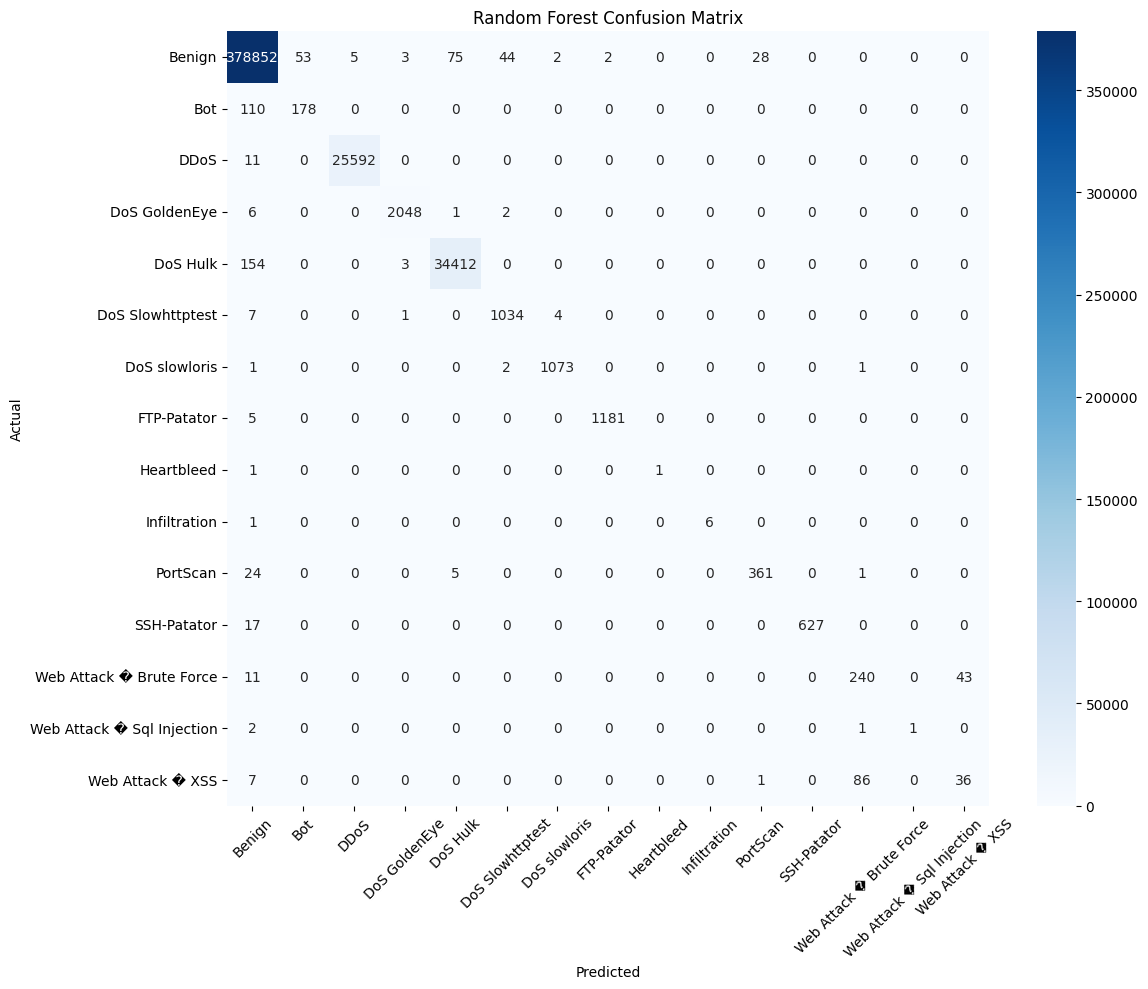

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=rf_model.classes_)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
 #Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(20))



                     Feature  Importance
66        Init Bwd Win Bytes    0.040091
6      Fwd Packet Length Max    0.036181
37             Bwd Packets/s    0.030824
15            Flow Packets/s    0.028282
18              Flow IAT Max    0.027863
20             Fwd IAT Total    0.027140
65        Init Fwd Win Bytes    0.026876
16             Flow IAT Mean    0.026479
5   Bwd Packets Length Total    0.026216
1              Flow Duration    0.025079
40        Packet Length Mean    0.024701
39         Packet Length Max    0.024589
68          Fwd Seg Size Min    0.023728
35         Bwd Header Length    0.023401
54      Avg Bwd Segment Size    0.022373
17              Flow IAT Std    0.022345
63       Subflow Bwd Packets    0.022135
23               Fwd IAT Max    0.021891
21              Fwd IAT Mean    0.021582
12    Bwd Packet Length Mean    0.021426


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# 1. Define a sample input row simulating a real-time network capture log
# (Replace this dictionary with your actual incoming live packet features)
new_packet_data = {
    "Protocol": 6,
    "Flow Duration": 609,
    "Total Fwd Packets": 7,
    "Total Backward Packets": 4,
    "Fwd Packets Length Total": 484,
    "Bwd Packets Length Total": 414,
    "Fwd Packet Length Max": 233,
    "Fwd Packet Length Min": 0,
    "Fwd Packet Length Mean": 69.14286,
    "Fwd Packet Length Std": 111.967896,
    "Bwd Packet Length Max": 350,
    "Bwd Packet Length Min": 0,
    "Bwd Packet Length Mean": 103.5,
    "Bwd Packet Length Std": 140.0,
    "Flow Bytes/s": 1474548.44,
    "Flow Packets/s": 18062.39,
    "Flow IAT Mean": 60.9,
    "Flow IAT Std": 110.5,
    "Flow IAT Max": 300,
    "Flow IAT Min": 1,
    "Fwd IAT Total": 609,
    "Fwd IAT Mean": 101.5,
    "Fwd IAT Std": 150.2,
    "Fwd IAT Max": 400,
    "Fwd IAT Min": 2,
    "Bwd IAT Total": 500,
    "Bwd IAT Mean": 125.0,
    "Bwd IAT Std": 130.0,
    "Bwd IAT Max": 350,
    "Bwd IAT Min": 5,
    "Fwd PSH Flags": 0,
    "Bwd PSH Flags": 0,
    "Fwd URG Flags": 0,
    "Bwd URG Flags": 0,
    "Fwd Header Length": 160,
    "Bwd Header Length": 100,
    "Fwd Packets/s": 11494.25,
    "Bwd Packets/s": 6568.14,
    "Packet Length Min": 0,
    "Packet Length Max": 350,
    "Packet Length Mean": 74.83,
    "Packet Length Std": 120.5,
    "Packet Length Variance": 14520.25,
    "FIN Flag Count": 0,
    "SYN Flag Count": 0,
    "RST Flag Count": 0,
    "PSH Flag Count": 1,
    "ACK Flag Count": 0,
    "URG Flag Count": 0,
    "CWE Flag Count": 0,
    "ECE Flag Count": 0,
    "Down/Up Ratio": 0,
    "Avg Packet Size": 81.63,
    "Avg Fwd Segment Size": 69.14,
    "Avg Bwd Segment Size": 103.5,
    "Fwd Avg Bytes/Bulk": 0,
    "Fwd Avg Packets/Bulk": 0,
    "Fwd Avg Bulk Rate": 0,
    "Bwd Avg Bytes/Bulk": 0,
    "Bwd Avg Packets/Bulk": 0,
    "Bwd Avg Bulk Rate": 0,
    "Subflow Fwd Packets": 7,
    "Subflow Fwd Bytes": 484,
    "Subflow Bwd Packets": 4,
    "Subflow Bwd Bytes": 414,
    "Init Fwd Win Bytes": 256,
    "Init Bwd Win Bytes": 225,
    "Fwd Act Data Packets": 5,
    "Fwd Seg Size Min": 20,
    "Active Mean": 0.0,
    "Active Std": 0.0,
    "Active Max": 0,
    "Active Min": 0,
    "Idle Mean": 0.0,
    "Idle Std": 0.0,
    "Idle Max": 0,
    "Idle Min": 0,
}

# 2. Convert raw dictionary structure into a DataFrame
input_df = pd.DataFrame([new_packet_data])


def preprocess_input(df_to_clean):
    """Cleans input logs to match the training pipeline metrics."""
    # Ensure column header white spaces are correctly removed
    df_to_clean.columns = df_to_clean.columns.str.strip()

    # Replaces unexpected infinite parameters with global NaN flag values
    df_to_clean = df_to_clean.replace([np.inf, -np.inf], np.nan)

    # Impute or drop fields containing bad entries (fill with 0 for safety in live runs)
    df_to_clean = df_to_clean.fillna(0)

    return df_to_clean


# Run processing pipeline
cleaned_input = preprocess_input(input_df)

# 3. Prediction Pipeline execution logic block
# Note: Ensure 'rf_model' object from your training cycle remains active/loaded in memory
try:
    # Run structural classification prediction tasks
    prediction = rf_model.predict(cleaned_input)
    prediction_probabilities = rf_model.predict_proba(cleaned_input)

    # Resolve active class labels matching maximum predicted indices
    max_prob_idx = np.argmax(prediction_probabilities)
    confidence_score = prediction_probabilities[0][max_prob_idx] * 100

    print("=" * 50)
    print(" INTRUSION DETECTION SYSTEM INFERENCE REPORT")
    print("=" * 50)
    print(f"Analysis Verdict : {prediction[0]}")
    print(f"Confidence Level : {confidence_score:.2f}%")

    if prediction[0].lower() == "benign":
        print("Status           : SAFE - Standard operational traffic volume detected.")
    else:
        print(f"Status           : !!! ALERT !!! Active Intrusion Category Spotted.")

    print("=" * 50)

except NameError:
    print(
        "Execution Error: The trained 'rf_model' object was not found. "
        "Please run your Random Forest training cell inside the notebook before testing new logs."
    )


 INTRUSION DETECTION SYSTEM INFERENCE REPORT
Analysis Verdict : Benign
Confidence Level : 99.00%
Status           : SAFE - Standard operational traffic volume detected.
